System: uname_result(system='Darwin', node='Kaylas-Air', release='23.6.0', version='Darwin Kernel Version 23.6.0: Fri Jul  5 18:01:46 PDT 2024; root:xnu-10063.141.1~2/RELEASE_ARM64_T8112', machine='arm64')  Threads 1
Python 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
numpy 1.26.4  scipy 1.13.1  h5py 3.11.0
Date: Thu Apr 23 13:23:19 2026
PySCF version 2.8.0
PySCF path  /opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 25
[INPUT] num. electrons = 142
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Ang
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 C     -8.215000000000  -0.694000000000  11.586000000000 AA  -15.524100113302  -1.311469930448  21.894366879211 Bohr   0.0
[INPUT]  2 C     -7.589000000000  -1.5150

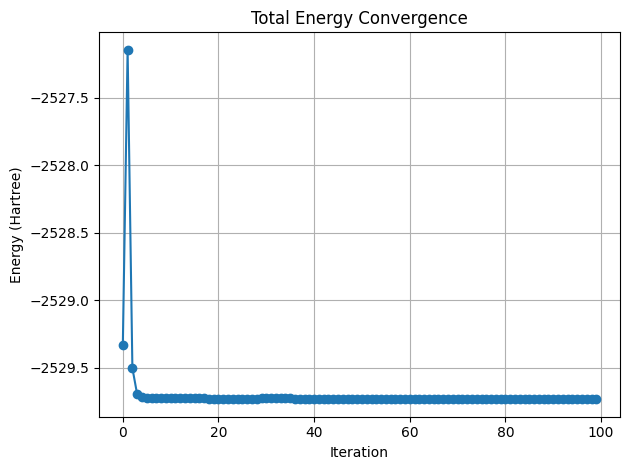

Saved energy convergence plot to: /Users/kaylarodriguez/Documents/pyscf-active-site-initial-tests/plots/pyscf_scf_energy_plot_2026-04-23_13-23-19.png


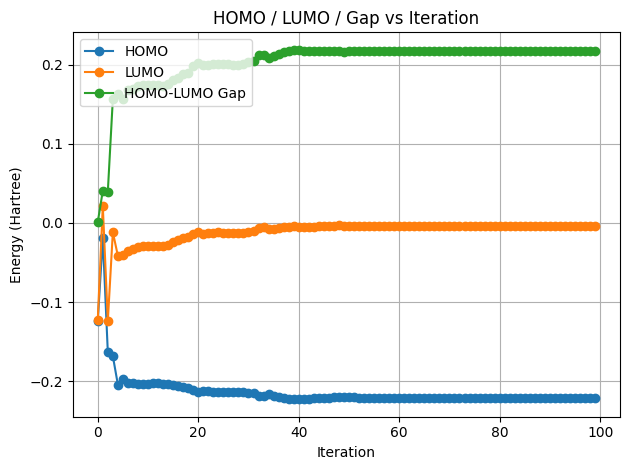

Saved HOMO-LUMO plot to: /Users/kaylarodriguez/Documents/pyscf-active-site-initial-tests/plots/pyscf_scf_homo_lumo_plot_2026-04-23_13-23-19.png


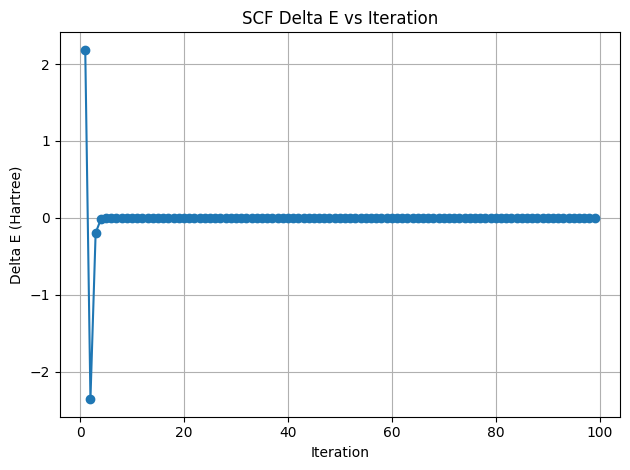

Saved delta E plot to: /Users/kaylarodriguez/Documents/pyscf-active-site-initial-tests/plots/pyscf_scf_deltaE_plot_2026-04-23_13-23-19.png


In [15]:
from pyscf import gto, dft
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import numpy as np
import os

ROOT_DIR = os.path.dirname(os.path.abspath("__file__"))

xyz_file = "active_site_202604222145.xyz"

with open(xyz_file, "r") as f:
    lines = f.readlines()

# Remove XYZ header
atom_block = "".join(lines[2:])

# DFT basis
#basis = "lanl2dz"
# basis = "cc-pvdz"
basis = "def2-svp"

# Make output folders if they do not exist
Path(f"{ROOT_DIR}/logs").mkdir(parents=True, exist_ok=True)
Path(f"{ROOT_DIR}/plots").mkdir(parents=True, exist_ok=True)

# Timestamp for output files
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Output filenames
log_file = Path(f"{ROOT_DIR}/logs/pyscf_scf_log_{timestamp}.txt")
energy_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_energy_plot_{timestamp}.png")
orbital_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_homo_lumo_plot_{timestamp}.png")
delta_e_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_deltaE_plot_{timestamp}.png")

mol = gto.M(
    atom=atom_block,
    basis=basis,
    charge=0,
    spin=0,
    unit="Ang",
    verbose=4
)

# Closed-shell system
mf = dft.RKS(mol)
mf.xc = "B3LYP"
mf.max_cycle = 100
mf.level_shift = 0.2

# Store SCF data
iterations = []
energies = []
delta_energies = []
homo_energies = []
lumo_energies = []
homo_lumo_gaps = []

def scf_callback(envs):
    cycle = envs["cycle"]
    e_tot = envs["e_tot"]

    # Save total energy
    iterations.append(cycle)
    energies.append(e_tot)

    # Compute delta E = E_n - E_(n-1)
    if len(energies) == 1:
        delta_e = np.nan
    else:
        delta_e = energies[-1] - energies[-2]
    delta_energies.append(delta_e)

    # Orbital energies and occupations at this SCF step
    mo_energy = envs.get("mo_energy", None)
    mo_occ = envs.get("mo_occ", None)

    if mo_energy is not None and mo_occ is not None:
        mo_energy = np.array(mo_energy)
        mo_occ = np.array(mo_occ)

        occupied = mo_energy[mo_occ > 0]
        virtual = mo_energy[mo_occ == 0]

        if len(occupied) > 0 and len(virtual) > 0:
            homo = occupied.max()
            lumo = virtual.min()
            gap = lumo - homo
        else:
            homo = np.nan
            lumo = np.nan
            gap = np.nan
    else:
        homo = np.nan
        lumo = np.nan
        gap = np.nan

    homo_energies.append(homo)
    lumo_energies.append(lumo)
    homo_lumo_gaps.append(gap)

mf.callback = scf_callback

# Run SCF
energy = mf.kernel()

print("\nFinal electronic energy (Hartree):", energy)
print("Converged:", mf.converged)
print("Number of electrons:", mol.nelectron)

# Save text log
with open(log_file, "w") as f:
    f.write("PySCF Run Log\n")
    f.write(f"Timestamp: {timestamp}\n")
    f.write(f"XYZ source file: {xyz_file}\n")
    f.write("Method: RKS\n")
    f.write(f"Functional: {mf.xc}\n")
    f.write(f"Basis: {basis}\n")
    f.write(f"Charge: {mol.charge}\n")
    f.write(f"Spin: {mol.spin}\n")
    f.write(f"Converged: {mf.converged}\n")
    f.write(f"Final electronic energy (Hartree): {energy:.12f}\n")
    f.write(f"Number of electrons: {mol.nelectron}\n")
    f.write("\nAtoms used in simulation:\n")
    f.write(atom_block)

    f.write("\nIteration Data:\n")
    f.write("Iteration\tEnergy_Hartree\tDeltaE_Hartree\tHOMO_Hartree\tLUMO_Hartree\tGap_Hartree\n")
    for i, e, de, h, l, g in zip(
        iterations, energies, delta_energies, homo_energies, lumo_energies, homo_lumo_gaps
    ):
        f.write(f"{i}\t{e:.12f}\t{de:.12f}\t{h:.12f}\t{l:.12f}\t{g:.12f}\n")

print(f"Saved SCF log to: {log_file}")

# Plot 1: total energy convergence
plt.figure()
plt.plot(iterations, energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("Total Energy Convergence")
plt.grid(True)
plt.tight_layout()
plt.savefig(energy_plot_file, dpi=300)
plt.show()

print(f"Saved energy convergence plot to: {energy_plot_file}")

# Plot 2: HOMO, LUMO, and HOMO-LUMO gap
plt.figure()
plt.plot(iterations, homo_energies, marker="o", label="HOMO")
plt.plot(iterations, lumo_energies, marker="o", label="LUMO")
plt.plot(iterations, homo_lumo_gaps, marker="o", label="HOMO-LUMO Gap")
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("HOMO / LUMO / Gap vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(orbital_plot_file, dpi=300)
plt.show()

print(f"Saved HOMO-LUMO plot to: {orbital_plot_file}")

# Plot 3: delta E vs iteration
plt.figure()
plt.plot(iterations, delta_energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Delta E (Hartree)")
plt.title("SCF Delta E vs Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig(delta_e_plot_file, dpi=300)
plt.show()

print(f"Saved delta E plot to: {delta_e_plot_file}")

In [ ]:
from pyscf import gto, dft
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import numpy as np
import os

ROOT_DIR = os.path.dirname(os.path.abspath("__file__"))

xyz_file = "active_site_202604222145.xyz"

with open(xyz_file, "r") as f:
    lines = f.readlines()

# Remove XYZ header
atom_block = "".join(lines[2:])

# DFT basis
#basis = "lanl2dz"
# basis = "cc-pvdz"
#basis = "def2-svp"
basis = "def2-TZVP"

# Make output folders if they do not exist
Path(f"{ROOT_DIR}/logs").mkdir(parents=True, exist_ok=True)
Path(f"{ROOT_DIR}/plots").mkdir(parents=True, exist_ok=True)

# Timestamp for output files
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Output filenames
log_file = Path(f"{ROOT_DIR}/logs/pyscf_scf_log_{timestamp}.txt")
energy_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_energy_plot_{timestamp}.png")
orbital_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_homo_lumo_plot_{timestamp}.png")
delta_e_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_deltaE_plot_{timestamp}.png")

mol = gto.M(
    atom=atom_block,
    basis=basis,
    charge=0,
    spin=0,
    unit="Ang",
    verbose=4
)

# Closed-shell system
mf = dft.RKS(mol)
mf.xc = "B3LYP"
mf.max_cycle = 100
mf.level_shift = 0.2

# Store SCF data
iterations = []
energies = []
delta_energies = []
homo_energies = []
lumo_energies = []
homo_lumo_gaps = []

def scf_callback(envs):
    cycle = envs["cycle"]
    e_tot = envs["e_tot"]

    # Save total energy
    iterations.append(cycle)
    energies.append(e_tot)

    # Compute delta E = E_n - E_(n-1)
    if len(energies) == 1:
        delta_e = np.nan
    else:
        delta_e = energies[-1] - energies[-2]
    delta_energies.append(delta_e)

    # Orbital energies and occupations at this SCF step
    mo_energy = envs.get("mo_energy", None)
    mo_occ = envs.get("mo_occ", None)

    if mo_energy is not None and mo_occ is not None:
        mo_energy = np.array(mo_energy)
        mo_occ = np.array(mo_occ)

        occupied = mo_energy[mo_occ > 0]
        virtual = mo_energy[mo_occ == 0]

        if len(occupied) > 0 and len(virtual) > 0:
            homo = occupied.max()
            lumo = virtual.min()
            gap = lumo - homo
        else:
            homo = np.nan
            lumo = np.nan
            gap = np.nan
    else:
        homo = np.nan
        lumo = np.nan
        gap = np.nan

    homo_energies.append(homo)
    lumo_energies.append(lumo)
    homo_lumo_gaps.append(gap)

mf.callback = scf_callback

# Run SCF
energy = mf.kernel()

print("\nFinal electronic energy (Hartree):", energy)
print("Converged:", mf.converged)
print("Number of electrons:", mol.nelectron)

# Save text log
with open(log_file, "w") as f:
    f.write("PySCF Run Log\n")
    f.write(f"Timestamp: {timestamp}\n")
    f.write(f"XYZ source file: {xyz_file}\n")
    f.write("Method: RKS\n")
    f.write(f"Functional: {mf.xc}\n")
    f.write(f"Basis: {basis}\n")
    f.write(f"Charge: {mol.charge}\n")
    f.write(f"Spin: {mol.spin}\n")
    f.write(f"Converged: {mf.converged}\n")
    f.write(f"Final electronic energy (Hartree): {energy:.12f}\n")
    f.write(f"Number of electrons: {mol.nelectron}\n")
    f.write("\nAtoms used in simulation:\n")
    f.write(atom_block)

    f.write("\nIteration Data:\n")
    f.write("Iteration\tEnergy_Hartree\tDeltaE_Hartree\tHOMO_Hartree\tLUMO_Hartree\tGap_Hartree\n")
    for i, e, de, h, l, g in zip(
        iterations, energies, delta_energies, homo_energies, lumo_energies, homo_lumo_gaps
    ):
        f.write(f"{i}\t{e:.12f}\t{de:.12f}\t{h:.12f}\t{l:.12f}\t{g:.12f}\n")

print(f"Saved SCF log to: {log_file}")

# Plot 1: total energy convergence
plt.figure()
plt.plot(iterations, energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("Total Energy Convergence")
plt.grid(True)
plt.tight_layout()
plt.savefig(energy_plot_file, dpi=300)
plt.show()

print(f"Saved energy convergence plot to: {energy_plot_file}")

# Plot 2: HOMO, LUMO, and HOMO-LUMO gap
plt.figure()
plt.plot(iterations, homo_energies, marker="o", label="HOMO")
plt.plot(iterations, lumo_energies, marker="o", label="LUMO")
plt.plot(iterations, homo_lumo_gaps, marker="o", label="HOMO-LUMO Gap")
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("HOMO / LUMO / Gap vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(orbital_plot_file, dpi=300)
plt.show()

print(f"Saved HOMO-LUMO plot to: {orbital_plot_file}")

# Plot 3: delta E vs iteration
plt.figure()
plt.plot(iterations, delta_energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Delta E (Hartree)")
plt.title("SCF Delta E vs Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig(delta_e_plot_file, dpi=300)
plt.show()

print(f"Saved delta E plot to: {delta_e_plot_file}")

System: uname_result(system='Darwin', node='Kaylas-Air', release='23.6.0', version='Darwin Kernel Version 23.6.0: Fri Jul  5 18:01:46 PDT 2024; root:xnu-10063.141.1~2/RELEASE_ARM64_T8112', machine='arm64')  Threads 1
Python 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
numpy 1.26.4  scipy 1.13.1  h5py 3.11.0
Date: Thu Apr 23 13:43:57 2026
PySCF version 2.8.0
PySCF path  /opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 25
[INPUT] num. electrons = 142
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Ang
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 C     -8.215000000000  -0.694000000000  11.586000000000 AA  -15.524100113302  -1.311469930448  21.894366879211 Bohr   0.0
[INPUT]  2 C     -7.589000000000  -1.5150

In [ ]:
from pyscf import gto, dft
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import numpy as np
import os

ROOT_DIR = os.path.dirname(os.path.abspath("__file__"))

xyz_file = "active_site_202604222145.xyz"

with open(xyz_file, "r") as f:
    lines = f.readlines()

# Remove XYZ header
atom_block = "".join(lines[2:])

# DFT basis
#basis = "lanl2dz"
# basis = "cc-pvdz"
#basis = "def2-svp"
#basis = "def2-TZVP"
basis = "def2-TZVPP"

# Make output folders if they do not exist
Path(f"{ROOT_DIR}/logs").mkdir(parents=True, exist_ok=True)
Path(f"{ROOT_DIR}/plots").mkdir(parents=True, exist_ok=True)

# Timestamp for output files
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Output filenames
log_file = Path(f"{ROOT_DIR}/logs/pyscf_scf_log_{timestamp}.txt")
energy_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_energy_plot_{timestamp}.png")
orbital_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_homo_lumo_plot_{timestamp}.png")
delta_e_plot_file = Path(f"{ROOT_DIR}/plots/pyscf_scf_deltaE_plot_{timestamp}.png")

mol = gto.M(
    atom=atom_block,
    basis=basis,
    charge=0,
    spin=0,
    unit="Ang",
    verbose=4
)

# Closed-shell system
mf = dft.RKS(mol)
mf.xc = "B3LYP"
mf.max_cycle = 100
mf.level_shift = 0.2

# Store SCF data
iterations = []
energies = []
delta_energies = []
homo_energies = []
lumo_energies = []
homo_lumo_gaps = []

def scf_callback(envs):
    cycle = envs["cycle"]
    e_tot = envs["e_tot"]

    # Save total energy
    iterations.append(cycle)
    energies.append(e_tot)

    # Compute delta E = E_n - E_(n-1)
    if len(energies) == 1:
        delta_e = np.nan
    else:
        delta_e = energies[-1] - energies[-2]
    delta_energies.append(delta_e)

    # Orbital energies and occupations at this SCF step
    mo_energy = envs.get("mo_energy", None)
    mo_occ = envs.get("mo_occ", None)

    if mo_energy is not None and mo_occ is not None:
        mo_energy = np.array(mo_energy)
        mo_occ = np.array(mo_occ)

        occupied = mo_energy[mo_occ > 0]
        virtual = mo_energy[mo_occ == 0]

        if len(occupied) > 0 and len(virtual) > 0:
            homo = occupied.max()
            lumo = virtual.min()
            gap = lumo - homo
        else:
            homo = np.nan
            lumo = np.nan
            gap = np.nan
    else:
        homo = np.nan
        lumo = np.nan
        gap = np.nan

    homo_energies.append(homo)
    lumo_energies.append(lumo)
    homo_lumo_gaps.append(gap)

mf.callback = scf_callback

# Run SCF
energy = mf.kernel()

print("\nFinal electronic energy (Hartree):", energy)
print("Converged:", mf.converged)
print("Number of electrons:", mol.nelectron)

# Save text log
with open(log_file, "w") as f:
    f.write("PySCF Run Log\n")
    f.write(f"Timestamp: {timestamp}\n")
    f.write(f"XYZ source file: {xyz_file}\n")
    f.write("Method: RKS\n")
    f.write(f"Functional: {mf.xc}\n")
    f.write(f"Basis: {basis}\n")
    f.write(f"Charge: {mol.charge}\n")
    f.write(f"Spin: {mol.spin}\n")
    f.write(f"Converged: {mf.converged}\n")
    f.write(f"Final electronic energy (Hartree): {energy:.12f}\n")
    f.write(f"Number of electrons: {mol.nelectron}\n")
    f.write("\nAtoms used in simulation:\n")
    f.write(atom_block)

    f.write("\nIteration Data:\n")
    f.write("Iteration\tEnergy_Hartree\tDeltaE_Hartree\tHOMO_Hartree\tLUMO_Hartree\tGap_Hartree\n")
    for i, e, de, h, l, g in zip(
        iterations, energies, delta_energies, homo_energies, lumo_energies, homo_lumo_gaps
    ):
        f.write(f"{i}\t{e:.12f}\t{de:.12f}\t{h:.12f}\t{l:.12f}\t{g:.12f}\n")

print(f"Saved SCF log to: {log_file}")

# Plot 1: total energy convergence
plt.figure()
plt.plot(iterations, energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("Total Energy Convergence")
plt.grid(True)
plt.tight_layout()
plt.savefig(energy_plot_file, dpi=300)
plt.show()

print(f"Saved energy convergence plot to: {energy_plot_file}")

# Plot 2: HOMO, LUMO, and HOMO-LUMO gap
plt.figure()
plt.plot(iterations, homo_energies, marker="o", label="HOMO")
plt.plot(iterations, lumo_energies, marker="o", label="LUMO")
plt.plot(iterations, homo_lumo_gaps, marker="o", label="HOMO-LUMO Gap")
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("HOMO / LUMO / Gap vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(orbital_plot_file, dpi=300)
plt.show()

print(f"Saved HOMO-LUMO plot to: {orbital_plot_file}")

# Plot 3: delta E vs iteration
plt.figure()
plt.plot(iterations, delta_energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Delta E (Hartree)")
plt.title("SCF Delta E vs Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig(delta_e_plot_file, dpi=300)
plt.show()

print(f"Saved delta E plot to: {delta_e_plot_file}")